<a href="https://colab.research.google.com/github/kenta-afk/cnn-lstm-model-for-valorant/blob/main/model-v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!unzip -q /content/cnn-lstm-project-images.zip -d /content/


In [3]:
import os

# List the contents of the unzipped directory
print(os.listdir('/content/cnn-lstm-project-images/'))

['sequence2', 'sequence1', 'sequence3', '.git', 'README.md', 'sequence4']


In [4]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping # Add this import
import numpy as np
import os
import cv2 # For image processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define image parameters
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
SEQUENCE_LENGTH = 8 # Number of frames per sequence for LSTM

print("Libraries imported and parameters defined.")

Libraries imported and parameters defined.


In [5]:
def load_and_preprocess_data(base_path, img_height, img_width, sequence_length):
    all_sequences = []
    all_labels = []
    label_names = []

    # Iterate through each sequence directory (e.g., sequence1, sequence2)
    for sequence_dir_name in sorted(os.listdir(base_path)):
        sequence_path = os.path.join(base_path, sequence_dir_name)
        # Skip non-directories, .git, and __MACOSX directories
        if not os.path.isdir(sequence_path) or sequence_dir_name in ['.git', '__MACOSX']:
            continue

        # Iterate through each action directory (e.g., 1.Mid defalt, 2.Brush)
        for action_dir_name in sorted(os.listdir(sequence_path)):
            action_path = os.path.join(sequence_path, action_dir_name)
            if not os.path.isdir(action_path):
                # Skip files within sequence directories (e.g., .DS_Store or images directly inside sequence folders)
                continue

            # Extract label, handling both 'Number.ActionName' and 'ActionName' formats
            parts = action_dir_name.split('.', 1)
            if len(parts) >= 2:
                label = parts[1].strip() # Use part after the first dot
            else:
                label = action_dir_name.strip() # Use the full directory name as label

            # Ensure label is not empty after stripping
            if not label:
                print(f"Warning: Skipping directory with empty label after processing: {action_dir_name} in {sequence_path}")
                continue

            if label not in label_names:
                label_names.append(label)

            images = []
            # Load all image paths in the current action directory
            for img_name in sorted(os.listdir(action_path)):
                # Ensure we handle both .jpg and .png files
                if img_name.endswith('.jpg') or img_name.endswith('.png'):
                    img_path = os.path.join(action_path, img_name)
                    images.append(img_path)

            # Create sequences of images and assign the label
            for i in range(0, len(images) - sequence_length + 1):
                sequence = images[i : i + sequence_length]
                all_sequences.append(sequence)
                all_labels.append(label)

    # Encode labels to integers
    label_encoder = LabelEncoder()
    # Check if there are any labels to encode before calling fit_transform
    if not all_labels:
        print("Error: No labels found after processing directories. Check data structure.")
        return np.array([]), np.array([]), 0, np.array([]) # Return empty arrays if no labels

    encoded_labels = label_encoder.fit_transform(all_labels)
    num_classes = len(label_encoder.classes_)

    # Load and preprocess images for each sequence
    X_processed = []
    y_processed = []

    for i, seq_paths in enumerate(all_sequences):
        sequence_frames = []
        for img_path in seq_paths:
            img = cv2.imread(img_path) # Load image
            if img is None:
                print(f"Warning: Could not load image {img_path}. Skipping sequence associated with {all_labels[i]}...")
                sequence_frames = [] # Clear frames to mark as incomplete
                break
            img = cv2.resize(img, (img_width, img_height)) # Resize image
            img = img / 255.0 # Normalize pixel values
            sequence_frames.append(img)

        if len(sequence_frames) == sequence_length: # Only add complete sequences
            X_processed.append(np.array(sequence_frames))
            y_processed.append(encoded_labels[i]) # Append the corresponding encoded label
        else:
            print(f"Warning: Skipping incomplete sequence (length {len(sequence_frames)} != {sequence_length}) for label {all_labels[i]}.")

    X = np.array(X_processed)
    y = np.array(y_processed)

    print(f"Loaded {len(X)} sequences.")
    print(f"Number of classes: {num_classes}")
    print(f"Class labels: {label_encoder.classes_}")

    return X, y, num_classes, label_encoder.classes_

# Base path for the minimap frames
BASE_DATA_PATH = '/content/cnn-lstm-project-images/'

# Load and preprocess data
X, y, num_classes, class_labels = load_and_preprocess_data(
    BASE_DATA_PATH, IMG_HEIGHT, IMG_WIDTH, SEQUENCE_LENGTH
)

# Split data into training and testing sets
# Ensure X and y are not empty before splitting
if len(X) > 0 and len(y) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")
else:
    print("No data loaded for training. Check data path and structure.")
    # Define X_train, X_test, y_train, y_test as empty arrays to prevent NameError in subsequent cells
    X_train, X_test, y_train, y_test = np.array([]), np.array([]), np.array([]), np.array([])

Loaded 133 sequences.
Number of classes: 8
Class labels: ['AreaHold' 'Brush' 'HoldBSite' 'Mid defalt' 'RegroupGoA' 'SlowGoA'
 'TakeAMain' 'TakeGarage']
X_train shape: (106, 8, 64, 64, 3)
y_train shape: (106,)
X_test shape: (27, 8, 64, 64, 3)
y_test shape: (27,)


In [43]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn_lstm_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # 1. 2D CNN部分（TimeDistributed が必須）
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu'))(inputs)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)

    # Global Pooling（各フレームを1次元ベクトルに圧縮）
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    # 2. 全結合・ドロップアウト（TimeDistributed なしで自動的に全時間軸へ適用される）
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # 3. LSTM部分（時間軸入力をそのまま受け取る）
    x = layers.LSTM(32, dropout=0.3)(x)

    # 4. 出力層
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Instantiate the model for 8-frame sequences
input_shape = (SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3)
model = build_cnn_lstm_model(input_shape, num_classes)

model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 8, 64, 64, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_78             │ (None, 8, 62, 62, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_79             │ (None, 8, 62, 62, 32)  │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_80             │ (None, 8, 31, 31, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_81             │ (None, 8, 32)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 8, 32)          │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,664 (41.66 KB)

 Trainable params: 10,600 (41.41 KB)

 Non-trainable params: 64 (256.00 B)

In [44]:
# Train the CNN-LSTM model on 8-frame sequences directly
if len(X_train) > 0 and len(X_test) > 0:
    history = model.fit(
        X_train,
        y_train,
        epochs=200,
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test)
    )
    print("Model training complete.")
else:
    print("No data available for training.")

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.1038 - loss: 2.0909 - val_accuracy: 0.1481 - val_loss: 2.0677
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1509 - loss: 2.0734 - val_accuracy: 0.1481 - val_loss: 2.0665
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1604 - loss: 2.0595 - val_accuracy: 0.1481 - val_loss: 2.0646
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1604 - loss: 2.0417 - val_accuracy: 0.1481 - val_loss: 2.0619
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.2358 - loss: 2.0216 - val_accuracy: 0.1481 - val_loss: 2.0582
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1981 - loss: 2.0235 - val_accuracy: 0.1481 - val_loss: 2.0546
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2358 - loss: 2.0189 - val_accuracy: 0.1481 - val_loss: 2.0512
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2547 - loss: 2.0156 - val_accuracy: 0.1481 - val_loss

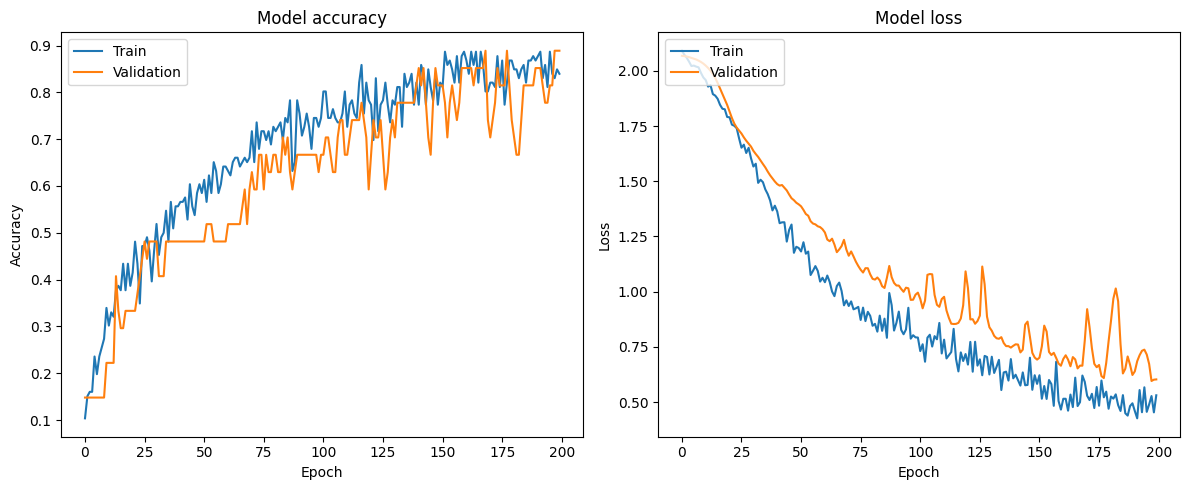

Training history plotted.


In [45]:
import matplotlib.pyplot as plt

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

print("Training history plotted.")

In [46]:
print('テストデータでの予測を開始します...')

# テストデータで予測を行う
y_pred_probs = model.predict(X_test)

# 確率から予測クラスを取得
y_pred = np.argmax(y_pred_probs, axis=1)

# クラス名に変換
actual_labels = [class_labels[label] for label in y_test]
predicted_labels = [class_labels[label] for label in y_pred]

# 結果を表示
import pandas as pd
results_df = pd.DataFrame({
    'Actual Label': actual_labels,
    'Predicted Label': predicted_labels
})

print('予測結果:')
display(results_df.head(10))

テストデータでの予測を開始します...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
予測結果:


,Actual Label,Predicted Label
0,RegroupGoA,RegroupGoA
1,Brush,Brush
2,HoldBSite,HoldBSite
3,TakeAMain,SlowGoA
4,SlowGoA,SlowGoA
5,RegroupGoA,RegroupGoA
6,SlowGoA,SlowGoA
7,SlowGoA,SlowGoA
8,RegroupGoA,RegroupGoA
9,RegroupGoA,RegroupGoA


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12505 (\N{KATAKANA LETTER BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

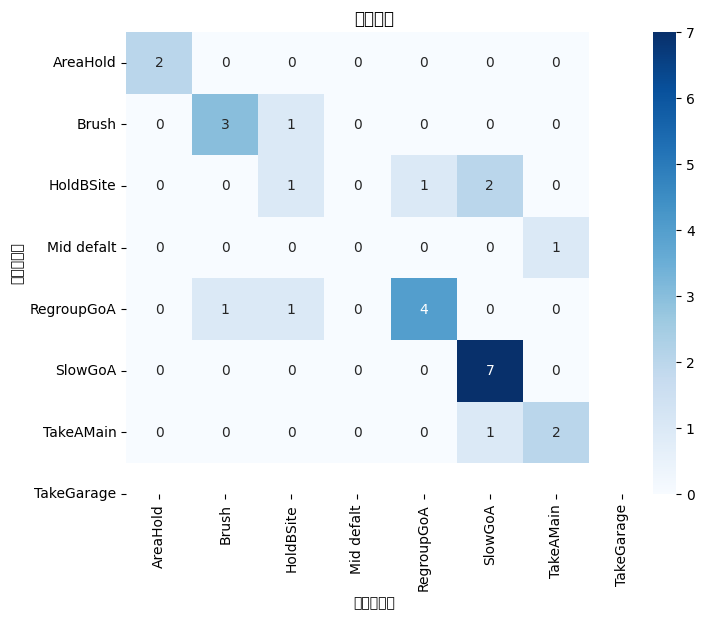


分類レポート:
              precision    recall  f1-score   support

    AreaHold       1.00      1.00      1.00         2
       Brush       0.75      0.75      0.75         4
   HoldBSite       0.33      0.25      0.29         4
  Mid defalt       0.00      0.00      0.00         1
  RegroupGoA       0.80      0.67      0.73         6
     SlowGoA       0.70      1.00      0.82         7
   TakeAMain       0.67      0.67      0.67         3
  TakeGarage       0.00      0.00      0.00         0

    accuracy                           0.70        27
   macro avg       0.53      0.54      0.53        27
weighted avg       0.67      0.70      0.68        27



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/me

In [39]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.arange

# 混同行列を計算
cm = confusion_matrix(y_test, y_pred)

# 混同行列をヒートマップで表示
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('予測ラベル')
plt.ylabel('真のラベル')
plt.title('混同行列')
plt.show()

# 分類レポートを表示
print('\n分類レポート:')
# Fix: Explicitly pass all possible labels to classification_report
print(classification_report(y_test, y_pred, labels=np.arange(num_classes), target_names=class_labels))
